# Notebook for constructing age models for the Cut Face Creek Sandstone

In [1]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Cut Face Creek sandstone

- Grand Marais rhyolite constrains the bottom of the strat
- Beaver River diabase intrusion constrains the top of the strat

In [2]:
Cut_Face_Name = ("Grand Marais rhyolite", "Beaver River diabase") # Et cetera
Cut_Face_Age           = [1093.52,  1091.7] # Measured ages
Cut_Face_Age_sigma     = [0.43/2,  0.2/2] # Measured 1-σ uncertainties
Cut_Face_Height        = [0,  95.13] # Depths below surface should be negative
Cut_Face_Age_Sidedness = [0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Cut_Face_Path = "../../data/age_models_output//Cut_Face" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Cut_Face_section = make_ChronAgeData(Cut_Face_Name, Cut_Face_Age, Cut_Face_Age_sigma, Cut_Face_Height, Cut_Face_Age_Sidedness, Cut_Face_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{2}(("Grand Marais rhyolite", "Beaver River diabase"), [0.0, 95.13], [0.01, 0.01], [1093.52, 1091.7], [0.215, 0.1], [NaN, NaN], [NaN, NaN], [NaN, NaN], [NaN, NaN], [0.0, 0.0], [0.0, 0.0], [#undef, #undef], (:Chronometer, :Chronometer), [NaN NaN; NaN NaN; … ; NaN NaN; NaN NaN], "../../data/age_models_output//Cut_Face", 2, "Ma", "m", :cdf)

In [3]:
Cut_Face_age_model_config, Cut_Face_age_model_mdl, Cut_Face_age_model_agedist, Cut_Face_age_model_lldist = run_age_model(Cut_Face_section, 0.2, 0.2, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 666000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 666000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(0.2, 666000, 1000, 666, 0.2), StratAgeModel([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8  …  93.2, 93.4, 93.6, 93.8, 94.0, 94.2, 94.4, 94.6, 94.8, 95.0], [1093.5336602854977, 1093.531107646018, 1093.52700102676, 1093.5232856417003, 1093.5193977629765, 1093.5155687774493, 1093.5111100777526, 1093.5075269999688, 1093.5031491904815, 1093.4993564156046  …  1091.7303504065778, 1091.726230778252, 1091.7231741291464, 1091.7186956788375, 1091.713826303217, 1091.7093006023106, 1091.7055119702713, 1091.7010561787895, 1091.6965287877313, 1091.6935689748057], [0.1720692039394054, 0.1735133418331923, 0.17662366000778904, 0.17889869178797688, 0.1824492399253386, 0.18282539872231904, 0.18511672996574258, 0.18858176030431792, 0.19067257844999413, 0.1923974180046744  …  0.13397715452613318, 0.13223015496854912, 0.13098658505358415, 0.1256900629932361, 0.11856922698329318, 0.11265155078039615, 0.10929960727988441, 0.1051166540193617, 0.10095466010437047, 0.09801731172418

### posterior summary age model

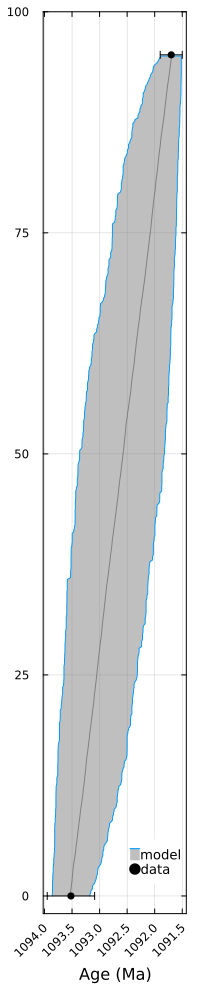

In [4]:
Cut_Face_age_model = plot_age_model(Cut_Face_section, Cut_Face_age_model_mdl, save_figure=false)
plot!(ylim=(-2, 100))
# savefig(Cut_Face_age_model, Cut_Face_section.Path*"_AgeDepthModel.pdf")
display(Cut_Face_age_model)

### example posterior accumulation models

In [11]:
function plot_accumulation_model(
    section,
    config,
    mdl,
    agedist;
    binwidth = 2,
    stepfrac = 0.1,   # fraction of binwidth between windows
    save_figure = false
)

    # ------------------------------------------------------------------
    # 1. Define sliding window geometry
    # ------------------------------------------------------------------
    agemin, agemax = extrema(mdl.Age)
    halfw = binwidth / 2
    Δt = binwidth * stepfrac
    println("agemin: $agemin, agemax: $agemax, halfw: $halfw, Δt: $Δt")
    centers = collect(range(agemin + halfw, agemax - halfw, step = Δt))
    println("Number of windows: $(length(centers))")
    if length(centers) < 1
        @warn "Age range too short for accumulation-rate estimation"
        return plot()
    end

    nwin = length(centers)
    nstep = config.nsteps

    # ------------------------------------------------------------------
    # 2. Allocate result array
    # ------------------------------------------------------------------
    dhdt_dist = Array{Float64}(undef, nwin, nstep)

    # ------------------------------------------------------------------
    # 3. Sliding-window rate calculation
    # ------------------------------------------------------------------
    @time for i in 1:nstep
        H = reverse(mdl.Height)
        T = reverse(agedist[:, i])

        for (j, tc) in enumerate(centers)
            t1 = tc - halfw
            t2 = tc + halfw

            h1 = linterp1(T, H, t1)
            h2 = linterp1(T, H, t2)

            dhdt_dist[j, i] = abs(h2 - h1) / binwidth
        end
    end

    # ------------------------------------------------------------------
    # 4. Ensemble statistics
    # ------------------------------------------------------------------
    dhdt_mean = nanmean(dhdt_dist, dims = 2)
    dhdt_med  = nanmedian(dhdt_dist, dims = 2)
    dhdt_16p  = nanpctile(dhdt_dist, 15.865, dims = 2)
    dhdt_84p  = nanpctile(dhdt_dist, 84.135, dims = 2)

    # ------------------------------------------------------------------
    # 5. Plot
    # ------------------------------------------------------------------
    hdl = plot(
        centers,
        dhdt_mean,
        label = "Mean",
        color = :black,
        linewidth = 2
    )

    plot!(
        hdl,
        [centers; reverse(centers)],
        [dhdt_16p; reverse(dhdt_84p)],
        fill = (0, 0.5, :darkblue),
        linealpha = 0,
        label = "68% CI"
    )

    plot!(
        hdl,
        centers,
        dhdt_med,
        label = "Median",
        color = :grey,
        linewidth = 1
    )

    plot!(
        hdl,
        xlabel = "Age ($(section.Age_Unit))",
        ylabel = "Emplacement Rate",
        framestyle = :box,
        fg_color_legend = :white,
        xflip = true
    )

    if save_figure
        savefig(hdl, section.Path * "DepositionRateModel.pdf")
    end

    return hdl
end

plot_accumulation_model (generic function with 1 method)

agemin: 1091.6935689748057, agemax: 1093.5336602854977, halfw: 0.5, Δt: 0.1
Number of windows: 9
  0.014754 seconds (9.00 k allocations: 11.902 MiB, 44.35% gc time)


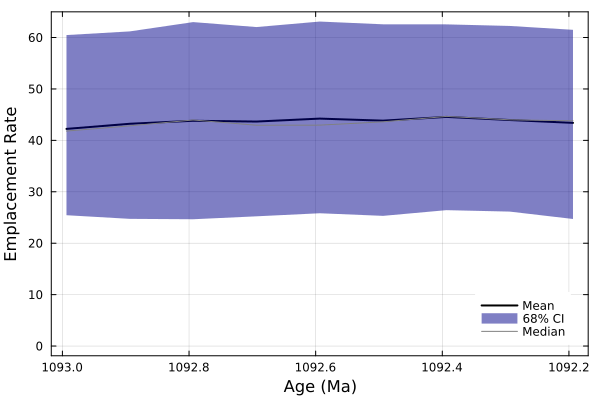

In [14]:
plot_accumulation_model(Cut_Face_section, Cut_Face_age_model_config, Cut_Face_age_model_mdl, Cut_Face_age_model_agedist, binwidth=1, stepfrac=0.1, save_figure=false)

### example posterior age models

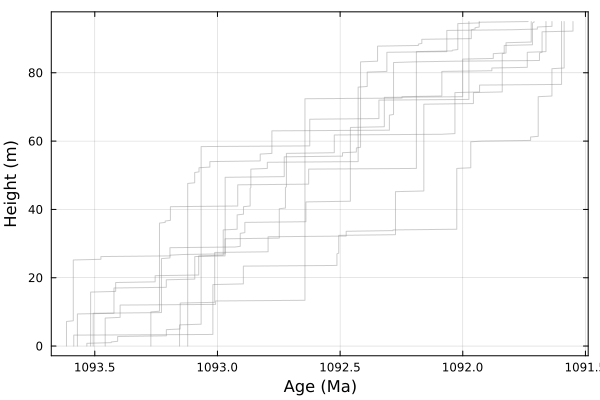

In [6]:
plot_posterior_paths(Cut_Face_section, Cut_Face_age_model_agedist, Cut_Face_age_model_mdl)

## save the age models to a file

In [7]:
Cut_Face_age_model_agedist

476×1000 Matrix{Float64}:
 1093.37  1093.18  1093.5  1093.06  …  1093.59  1093.19  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06  …  1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
 1093.37  1093.18  1093.5  1093.06     1093.59  1093.16  1093.8   1093.37
    ⋮                               ⋱                             
 1091.76  1091.86  1091.9  1091.7      1091.69  1091.89  1091.79  1091.55
 1091.76  1091.86  1091.9  1091.7      1091.69  1091.89  1091.79  1091.55
 1091.76  1091.86  

In [8]:
# use the mdl.height as index, agedist as the data
Cut_Face_age_models_df = DataFrame(hcat(Cut_Face_age_model_mdl.Height, Cut_Face_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Cut_Face_age_models_df, Dict(:x1 => "height"))
Cut_Face_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1093.37,1093.18,1093.5,1093.06,1093.42,1093.57,1093.45,1093.4,1093.38,1093.91,1093.28,1093.66,1093.41,1093.62,1093.63,1093.29,1093.51,1093.58,1093.38,1093.5,1093.73,1093.63,1093.58,1093.09,1093.45,1093.41,1093.43,1093.53,1093.55,1093.32,1093.25,1093.3,1093.36,1093.77,1093.65,1093.64,1093.39,1093.64,1093.36,1093.41,1093.81,1093.72,1093.62,1093.12,1093.39,1093.74,1093.47,1093.45,1093.81,1093.42,1093.45,1093.67,1093.47,1093.53,1093.73,1093.6,1093.76,1093.86,1093.45,1093.64,1093.35,1093.54,1093.41,1093.67,1093.58,1093.53,1093.67,1093.51,1093.6,1093.35,1093.49,1093.33,1093.47,1093.16,1093.17,1093.66,1093.41,1093.36,1093.49,1093.41,1093.59,1093.5,1093.86,1093.59,1093.45,1093.6,1093.73,1093.79,1093.9,1093.56,1093.32,1093.45,1093.71,1093.61,1093.6,1093.55,1093.54,1093.58,1093.53,⋯
2,0.2,1093.37,1093.18,1093.5,1093.06,1093.42,1093.57,1093.45,1093.4,1093.38,1093.91,1093.28,1093.66,1093.41,1093.62,1093.46,1093.29,1093.51,1093.58,1093.38,1093.5,1093.73,1093.63,1093.58,1093.09,1093.45,1093.41,1093.43,1093.53,1093.55,1093.32,1093.25,1093.3,1093.36,1093.77,1093.65,1093.64,1093.39,1093.64,1093.36,1093.41,1093.81,1093.72,1093.62,1093.12,1093.39,1093.74,1093.47,1093.45,1093.81,1093.42,1093.45,1093.41,1093.47,1093.53,1093.73,1093.37,1093.76,1093.86,1093.45,1093.64,1093.35,1093.54,1093.41,1093.67,1093.58,1093.53,1093.67,1093.51,1093.6,1093.35,1093.49,1093.33,1093.47,1093.16,1093.17,1093.66,1093.41,1093.36,1093.49,1093.41,1093.59,1093.5,1093.86,1093.59,1093.45,1093.6,1093.73,1093.79,1093.9,1093.56,1093.32,1093.45,1093.71,1093.61,1093.6,1093.55,1093.54,1093.58,1093.53,⋯
3,0.4,1093.37,1093.18,1093.5,1093.06,1093.42,1093.57,1093.45,1093.4,1093.38,1093.91,1093.28,1093.66,1093.41,1093.62,1093.46,1093.29,1093.51,1093.58,1093.38,1093.5,1093.73,1093.63,1093.58,1093.09,1093.45,1093.41,1093.43,1093.53,1093.55,1093.32,1093.25,1093.3,1093.36,1093.77,1093.65,1093.64,1093.39,1093.64,1093.36,1093.3,1093.81,1093.72,1093.62,1092.85,1093.39,1093.74,1093.47,1093.45,1093.81,1093.42,1093.45,1093.41,1093.47,1093.53,1093.73,1093.37,1093.76,1093.86,1093.45,1093.64,1093.35,1093.54,1093.25,1093.67,1093.58,1093.53,1093.67,1093.51,1093.6,1093.35,1093.49,1093.33,1093.47,1093.08,1093.17,1093.66,1093.41,1093.36,1093.49,1093.41,1093.59,1093.5,1093.86,1093.59,1093.45,1093.6,1093.73,1093.79,1093.9,1093.56,1093.32,1093.41,1093.71,1093.61,1093.57,1093.55,1093.54,1093.58,1093.53,⋯
4,0.6,1093.37,1093.18,1093.5,1093.06,1093.42,1093.57,1093.45,1093.4,1093.38,1093.91,1093.28,1093.66,1093.41,1093.62,1093.46,1093.29,1093.51,1093.58,1093.38,1093.5,1093.73,1093.63,1093.58,1093.09,1093.45,1093.41,1093.43,1093.53,1093.55,1093.16,1093.25,1093.17,1093.36,1093.77,1093.65,1093.64,1093.39,1093.64,1093.36,1093.3,1093.81,1093.72,1093.62,1092.85,1093.39,1093.74,1093.47,1093.45,1093.81,1093.42,1093.45,1093.41,1093.

In [9]:
# write the DataFrame to a csv file
CSV.write(Cut_Face_section.Path*"_posterior_ages.csv", Cut_Face_age_models_df)

"../../data/age_models_output//Cut_Face_posterior_ages.csv"